<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana7/MonteCarloIntegration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
x = np.random.uniform(0,2,1000)

In [25]:
def IntegracionMC(a=0,b=2,N=1000000, seed=7):

  np.random.seed(seed)
  x = np.random.uniform(a,b,N)
  #print(x)
  # Evaluamos la funcion en el soporte
  f = x**2

  # La integral
  I = (b-a)*np.mean(f)

  error = (b-a)*np.std(f, ddof=1)/np.sqrt(N)

  return I,error

In [26]:
I,error = IntegracionMC()
print(8/3,I)
print(error)

2.6666666666666665 2.666750076061984
0.0023849636499946787


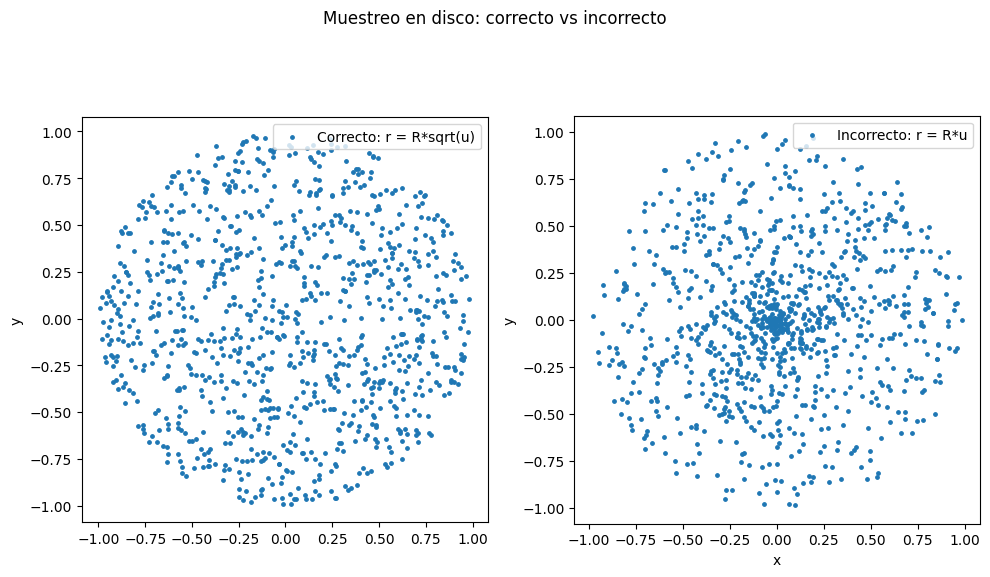

In [37]:


def disco_sampling_comparacion(R=1.0, N=100):


    # -------------------------
    # CORRECTO: uniforme en área
    # -------------------------
    u = np.random.rand(N)
    v = np.random.rand(N)
    r_ok = R * np.sqrt(u)
    th_ok = 2*np.pi * v
    x_ok = r_ok * np.cos(th_ok)
    y_ok = r_ok * np.sin(th_ok)

    # -------------------------
    # INCORRECTO: r uniforme (sesgo al centro)
    # -------------------------
    u2 = np.random.rand(N)
    v2 = np.random.rand(N)
    r_bad = R * u2
    th_bad = 2*np.pi * v2
    x_bad = r_bad * np.cos(th_bad)
    y_bad = r_bad * np.sin(th_bad)


    fig, ax = plt.subplots(1, 2, figsize=(10,6))
    ax[0].scatter(x_ok,  y_ok,  s=6, label="Correcto: r = R*sqrt(u)")
    ax[1].scatter(x_bad, y_bad, s=6, label="Incorrecto: r = R*u")
    ax[0].set_aspect('equal', 'box')
    ax[1].set_aspect('equal', 'box')
    fig.suptitle("Muestreo en disco: correcto vs incorrecto")
    ax[0].set_ylabel("y")
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")
    ax[0].legend()
    ax[1].legend()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

if __name__ == "__main__":
    disco_sampling_comparacion(R=1.0, N=1000)

In [34]:
#Calculemos el momento de inercia
def Momento(R=1, N=10000, seed=0):

  u = np.random.uniform(0,1,N)
  v = np.random.uniform(0,1,N)

  r = R*np.sqrt(u)
  th = 2*np.pi*v

  x = r*np.cos(th)
  y = r*np.sin(th)

  f = x**2 + y**2

  I = np.pi*R**2 * np.mean(f)

  error = np.pi*R**2 * np.std(f, ddof=1)/np.sqrt(N)

  return I,error

In [35]:
Momento()

(np.float64(1.5695871772439853), np.float64(0.008977184655022384))